# Recursion

In [ ]:
class Solution:
    def canPartition(self, nums):
        total = sum(nums)

        # If total sum is odd, cannot split equally
        if total % 2 != 0:
            return False

        target = total // 2

        def solve(index, remaining):

            # Found subset with target sum
            if remaining == 0:
                return True

            # Out of bounds or exceeded target
            if index >= len(nums) or remaining < 0:
                return False

            # Include current number OR skip it
            return (
                solve(index + 1, remaining - nums[index]) or
                solve(index + 1, remaining)
            )

        return solve(0, target)

Transition comes directly from your recursion:

solve(i, remaining)

=
take current number
OR
skip current number



Converted to DP:

dp[i][s] =

dp[i-1][s]                 # skip

OR

dp[i-1][s-nums[i-1]]       # take

# 2D DP

In [ ]:
class Solution:
    def canPartition(self, nums):
        total = sum(nums)

        # If total sum is odd, cannot split equally
        if total % 2 != 0:
            return False

        target = total // 2
        n = len(nums)

        # dp[i][s] = can we make sum s using first i numbers
        dp = [[False] * (target + 1) for _ in range(n + 1)]

        # Sum 0 is always possible
        for i in range(n + 1):
            dp[i][0] = True

        for i in range(1, n + 1):
            for s in range(1, target + 1):

                # Skip current number
                dp[i][s] = dp[i - 1][s]

                # Include current number if possible
                if s >= nums[i - 1]:
                    dp[i][s] = (
                        dp[i][s] or
                        dp[i - 1][s - nums[i - 1]]
                    )

        return dp[n][target]

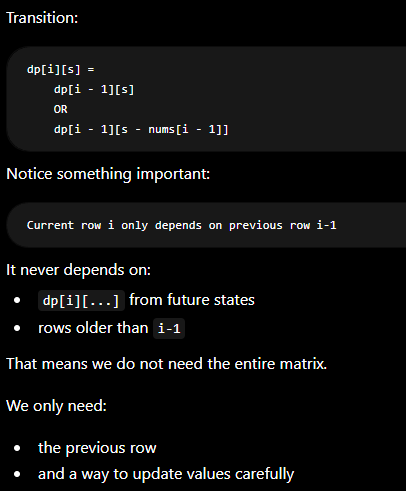

In [ ]:
class Solution:
    def canPartition(self, nums):
        total = sum(nums)

        if total % 2 != 0:
            return False

        target = total // 2

        dp = [False] * (target + 1)
        dp[0] = True

        for num in nums:
            for s in range(target, num - 1, -1):
                dp[s] = dp[s] or dp[s - num]

        return dp[target]